In [3]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## hacerlo mas adelante --> llevamos las funciones a los archivos que correspondan 
import src.exploracion as exp
import src.transformación as trs
import src.visualizacion as viz

In [4]:
df_titanic = pd.read_csv("data/titanic.csv")
def descripcion_df():
    print(f"Esto tiene: {df_titanic.shape[0]} filas y {df_titanic.shape[1]} columnas")
    print (f"Tiene un total de: {df_titanic.isna().sum().values.sum()} valores nulos")

In [5]:
# Eliminar las columnas:
df_titanic_1 = df_titanic.drop(columns=['survived', 'pclass', 'sibsp', 'parch', 'fare', 'embarked', 'adult_male', 'deck', 'alone'])

In [6]:
# Eliminar las filas con datos faltantes en la columna: 'embark_town' y sustituir valores faltantes en 'age' por su media
df_titanic_2 = df_titanic_1.dropna(subset=['embark_town']).fillna(df_titanic_1['age'].mean())
df_titanic_2

,sex,age,class,who,embark_town,alive
0,male,22.000000,Third,man,Southampton,no
1,female,38.000000,First,woman,Cherbourg,yes
2,female,26.000000,Third,woman,Southampton,yes
3,female,35.000000,First,woman,Southampton,yes
4,male,35.000000,Third,man,Southampton,no
...,...,...,...,...,...,...
886,male,27.000000,Second,man,Southampton,no
887,female,19.000000,First,woman,Southampton,yes
888,female,29.699118,Third,woman,Southampton,no
889,male,26.000000,First,man,Cherbourg,yes


In [5]:
def titanic_limpio (df_titanic):
    df_titanic_1 = df_titanic.drop(columns=['survived', 'pclass', 'sibsp', 'parch', 'fare', 'embarked', 'adult_male', 'deck', 'alone'])
    df_titanic_2 = df_titanic_1.dropna(subset=['embark_town']).fillna(df_titanic_1['age'].mean())
    return df_titanic_2

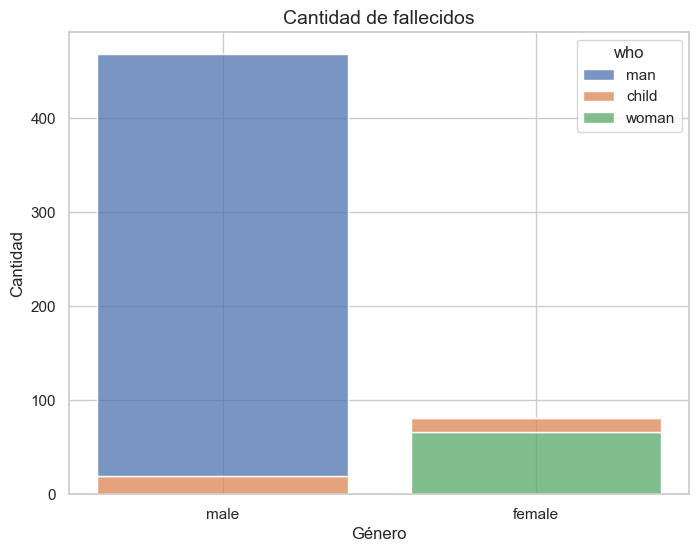

In [11]:
# 1º grafico #
muertos = df_titanic_2[df_titanic_2["alive"]=="no"]

plt.figure(figsize=(8, 6))
grafico = sns.histplot(data=muertos, x="sex", hue="who", multiple="stack", shrink=0.8, discrete=True)
plt.xlabel("Género", fontsize=12)
plt.ylabel("Cantidad", fontsize=12)
plt.title("Cantidad de fallecidos", fontsize=14)
plt.savefig("imagenes/fallecidos_sexo.png")
plt.show();

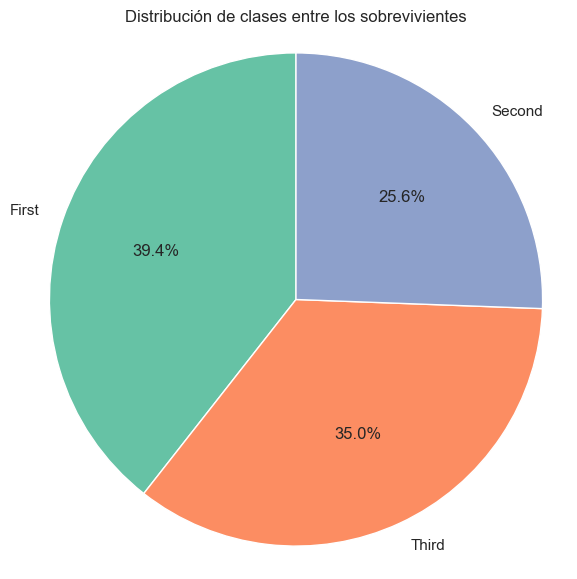

In [12]:
# 2º grafico # 
vivos = df_titanic_2[df_titanic_2["alive"]=="yes"]
categoria = vivos['class'].value_counts()

sns.set(style="whitegrid")
plt.figure(figsize=(7, 7))
plt.pie(categoria, labels=categoria.index, autopct='%1.1f%%',startangle=90, colors=sns.color_palette("Set2", len(categoria)))
plt.title('Distribución de clases entre los sobrevivientes')
plt.axis('equal')  
plt.savefig("imagenes/categoria_vivos.png")
plt.show();